<a href="https://www.kaggle.com/code/lalit7881/it-job-seekers-skills-87-54?scriptVersionId=343862331" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ameliaberignton/it-job-seekers-skills/candidates_full.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ameliaberignton/it-job-seekers-skills/candidates_full.csv")

In [3]:
df.head()

,candidate_id,job_role,job_role_display,gender,age_group,edu_level,edu_level_name,years_experience,edu_relevance,P_mcq,...,passed_hard_filter,relevance_label,w_edu,w_exp,w_skill,w_mcq,w_desc,w_code,W_CV,W_INT
0,SE00001,Software_Engineer,Software Engineer,M,40+,3,MSc,1.2,0.7246,0.7925,...,0,2,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
1,SE00002,Software_Engineer,Software Engineer,M,26-30,2,BSc,0.0,0.5713,0.6344,...,0,1,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
2,SE00003,Software_Engineer,Software Engineer,M,31-35,2,BSc,10.4,0.7052,0.6523,...,1,3,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
3,SE00004,Software_Engineer,Software Engineer,M,31-35,2,BSc,4.0,0.5019,0.5709,...,1,1,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
4,SE00005,Software_Engineer,Software Engineer,M,22-25,4,PhD,4.5,0.8334,0.5413,...,1,1,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6


In [4]:
df.tail()

,candidate_id,job_role,job_role_display,gender,age_group,edu_level,edu_level_name,years_experience,edu_relevance,P_mcq,...,passed_hard_filter,relevance_label,w_edu,w_exp,w_skill,w_mcq,w_desc,w_code,W_CV,W_INT
11995,EMB00596,Embedded_Systems_Engineer,Embedded Systems Engineer,M,22-25,3,MSc,7.6,0.695,0.8664,...,1,3,0.2,0.35,0.45,0.25,0.3,0.45,0.4,0.6
11996,EMB00597,Embedded_Systems_Engineer,Embedded Systems Engineer,M,36-40,3,MSc,6.2,0.824,0.7825,...,1,2,0.2,0.35,0.45,0.25,0.3,0.45,0.4,0.6
11997,EMB00598,Embedded_Systems_Engineer,Embedded Systems Engineer,M,36-40,2,BSc,4.1,0.675,0.8299,...,1,1,0.2,0.35,0.45,0.25,0.3,0.45,0.4,0.6
11998,EMB00599,Embedded_Systems_Engineer,Embedded Systems Engineer,M,26-30,3,MSc,4.5,0.661,0.9435,...,1,3,0.2,0.35,0.45,0.25,0.3,0.45,0.4,0.6
11999,EMB00600,Embedded_Systems_Engineer,Embedded Systems Engineer,M,31-35,4,PhD,4.3,0.827,0.5819,...,1,3,0.2,0.35,0.45,0.25,0.3,0.45,0.4,0.6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   candidate_id        12000 non-null  object 
 1   job_role            12000 non-null  object 
 2   job_role_display    12000 non-null  object 
 3   gender              12000 non-null  object 
 4   age_group           12000 non-null  object 
 5   edu_level           12000 non-null  int64  
 6   edu_level_name      12000 non-null  object 
 7   years_experience    12000 non-null  float64
 8   edu_relevance       12000 non-null  float64
 9   P_mcq               12000 non-null  float64
 10  P_desc              12000 non-null  float64
 11  P_code              12000 non-null  float64
 12  S_edu               12000 non-null  float64
 13  S_exp               12000 non-null  float64
 14  S_skill             12000 non-null  float64
 15  S_cv                12000 non-null  float64
 16  S_in

In [6]:
df.describe()

,edu_level,years_experience,edu_relevance,P_mcq,P_desc,P_code,S_edu,S_exp,S_skill,S_cv,...,passed_hard_filter,relevance_label,w_edu,w_exp,w_skill,w_mcq,w_desc,w_code,W_CV,W_INT
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04,1.200000e+04
mean,2.441167,4.042050,0.673524,0.759571,0.748888,0.779324,0.682349,0.847342,0.713764,0.753719,...,0.784000,2.081417,0.195000,0.332500,0.472500,0.257500,0.365000,0.377500,4.000000e-01,6.000000e-01
std,0.716762,2.343824,0.141287,0.135562,0.160250,0.165866,0.117395,0.286323,0.139180,0.131132,...,0.411531,0.936409,0.041535,0.042649,0.053563,0.048155,0.077624,0.120913,1.332323e-15,1.203532e-13
min,1.000000,0.000000,0.100000,0.290400,0.193800,0.146900,0.310300,0.000000,0.187400,0.204700,...,0.000000,0.000000,0.150000,0.250000,0.400000,0.200000,0.300000,0.150000,4.000000e-01,6.000000e-01
25%,2.000000,2.300000,0.581000,0.661175,0.635100,0.662275,0.604700,0.833300,0.617700,0.693575,...,1.000000,2.000000,0.150000,0.300000,0.450000,0.200000,0.300000,0.275000,4.000000e-01,6.000000e-01
50%,2.000000,3.900000,0.679050,0.759100,0.757150,0.791100,0.663850,1.000000,0.716100,0.781050,...,1.000000,2.000000,0.200000,0.325000,0.450000,0.250000,0.350000,0.400000,4.000000e-01,6.000000e-01
75%,3.000000,5.600000,0.769000,0.858600,0.874200,0.919900,0.765600,1.000000,0.811425,0.844600,...,1.000000,3.000000,0.200000,0.350000,0.512500,0.300000,0.412500,0.500000,4.000000e-01,6.000000e-01
max,4.000000,13.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.998400,...,1.000000,3.000000,0.300000,0.400000,0.550000,0.350000,0.500000,0.500000,4.000000e-01,6.000000e-01


In [7]:
df.isnull().sum()

candidate_id          0
job_role              0
job_role_display      0
gender                0
age_group             0
edu_level             0
edu_level_name        0
years_experience      0
edu_relevance         0
P_mcq                 0
P_desc                0
P_code                0
S_edu                 0
S_exp                 0
S_skill               0
S_cv                  0
S_int                 0
CSS                   0
passed_hard_filter    0
relevance_label       0
w_edu                 0
w_exp                 0
w_skill               0
w_mcq                 0
w_desc                0
w_code                0
W_CV                  0
W_INT                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

candidate_id           object
job_role               object
job_role_display       object
gender                 object
age_group              object
edu_level               int64
edu_level_name         object
years_experience      float64
edu_relevance         float64
P_mcq                 float64
P_desc                float64
P_code                float64
S_edu                 float64
S_exp                 float64
S_skill               float64
S_cv                  float64
S_int                 float64
CSS                   float64
passed_hard_filter      int64
relevance_label         int64
w_edu                 float64
w_exp                 float64
w_skill               float64
w_mcq                 float64
w_desc                float64
w_code                float64
W_CV                  float64
W_INT                 float64
dtype: object

In [10]:
df.columns

Index(['candidate_id', 'job_role', 'job_role_display', 'gender', 'age_group',
       'edu_level', 'edu_level_name', 'years_experience', 'edu_relevance',
       'P_mcq', 'P_desc', 'P_code', 'S_edu', 'S_exp', 'S_skill', 'S_cv',
       'S_int', 'CSS', 'passed_hard_filter', 'relevance_label', 'w_edu',
       'w_exp', 'w_skill', 'w_mcq', 'w_desc', 'w_code', 'W_CV', 'W_INT'],
      dtype='object')

In [11]:
df.shape

(12000, 28)

In [12]:
df.nunique()

candidate_id          12000
job_role                 20
job_role_display         20
gender                    2
age_group                 7
edu_level                 4
edu_level_name            4
years_experience        132
edu_relevance          3932
P_mcq                  4518
P_desc                 4920
P_code                 4741
S_edu                  3781
S_exp                    99
S_skill                4778
S_cv                   4420
S_int                  4436
CSS                    4096
passed_hard_filter        2
relevance_label           4
w_edu                     4
w_exp                     4
w_skill                   4
w_mcq                     4
w_desc                    5
w_code                    7
W_CV                      1
W_INT                     1
dtype: int64

## EDA


DATA TYPES
candidate_id           object
job_role               object
job_role_display       object
gender                 object
age_group              object
edu_level               int64
edu_level_name         object
years_experience      float64
edu_relevance         float64
P_mcq                 float64
P_desc                float64
P_code                float64
S_edu                 float64
S_exp                 float64
S_skill               float64
S_cv                  float64
S_int                 float64
CSS                   float64
passed_hard_filter      int64
relevance_label         int64
w_edu                 float64
w_exp                 float64
w_skill               float64
w_mcq                 float64
w_desc                float64
w_code                float64
W_CV                  float64
W_INT                 float64
dtype: object

MISSING VALUES
candidate_id          0
job_role              0
job_role_display      0
gender                0
age_group             

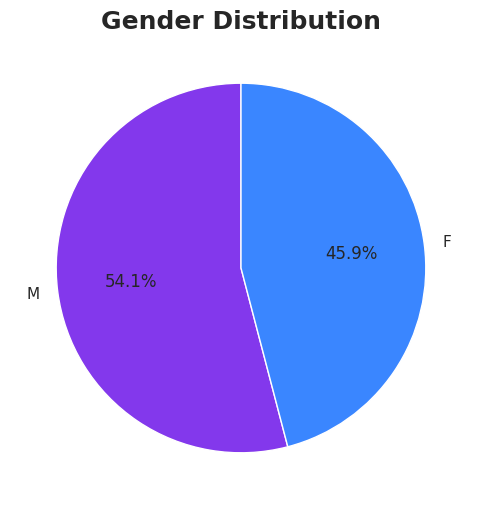

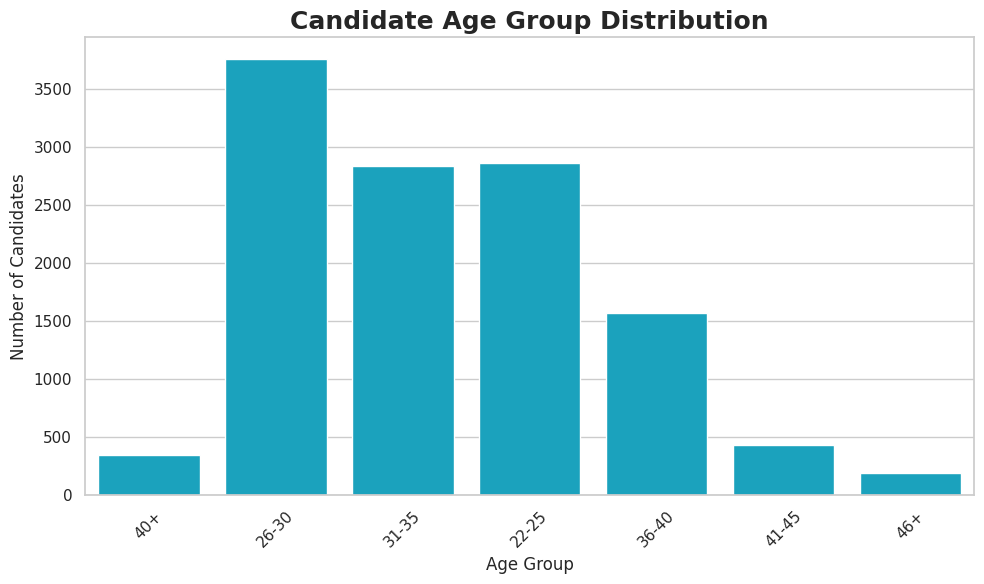

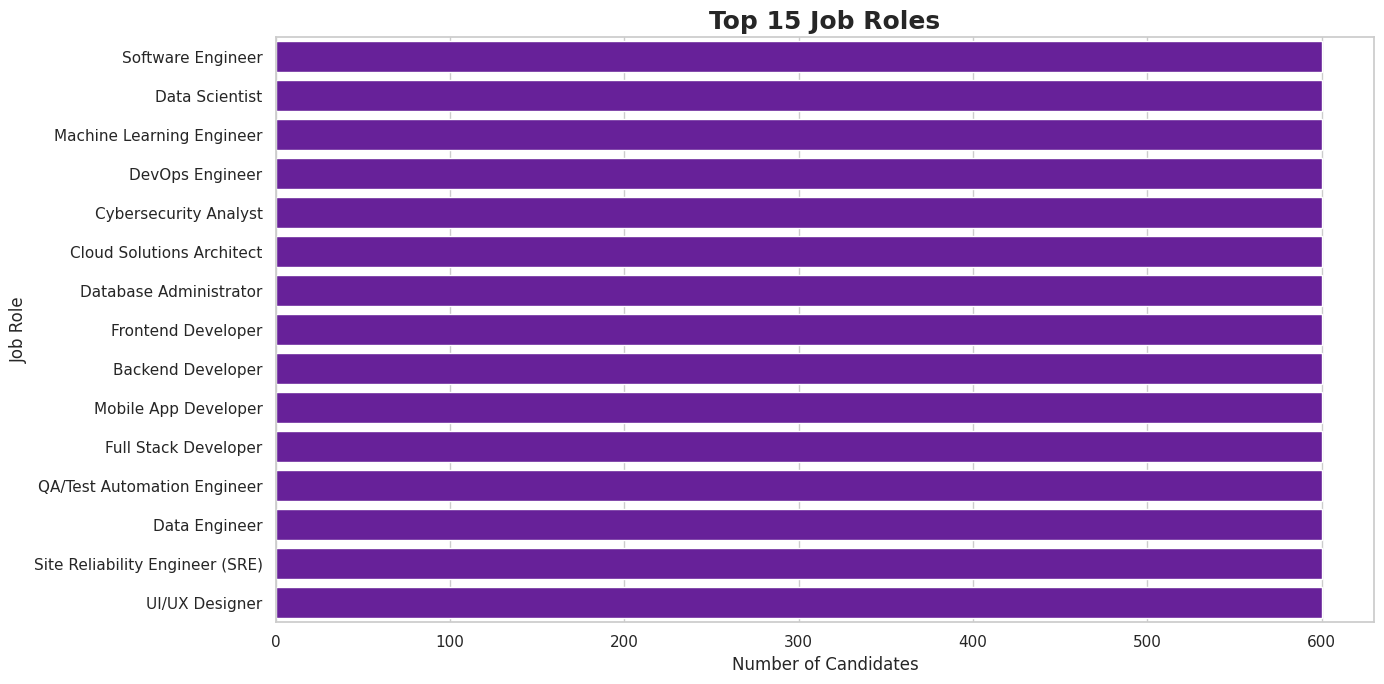

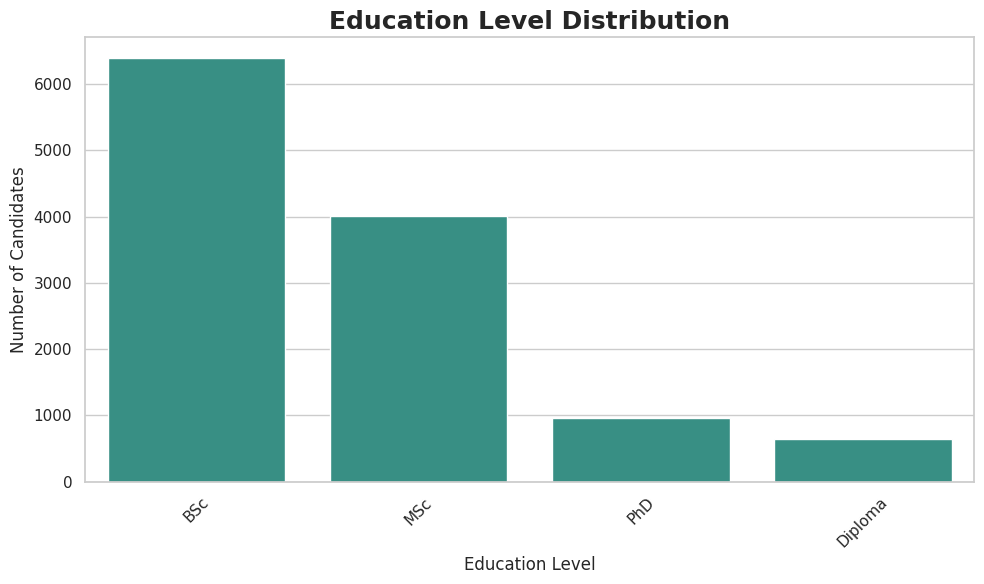

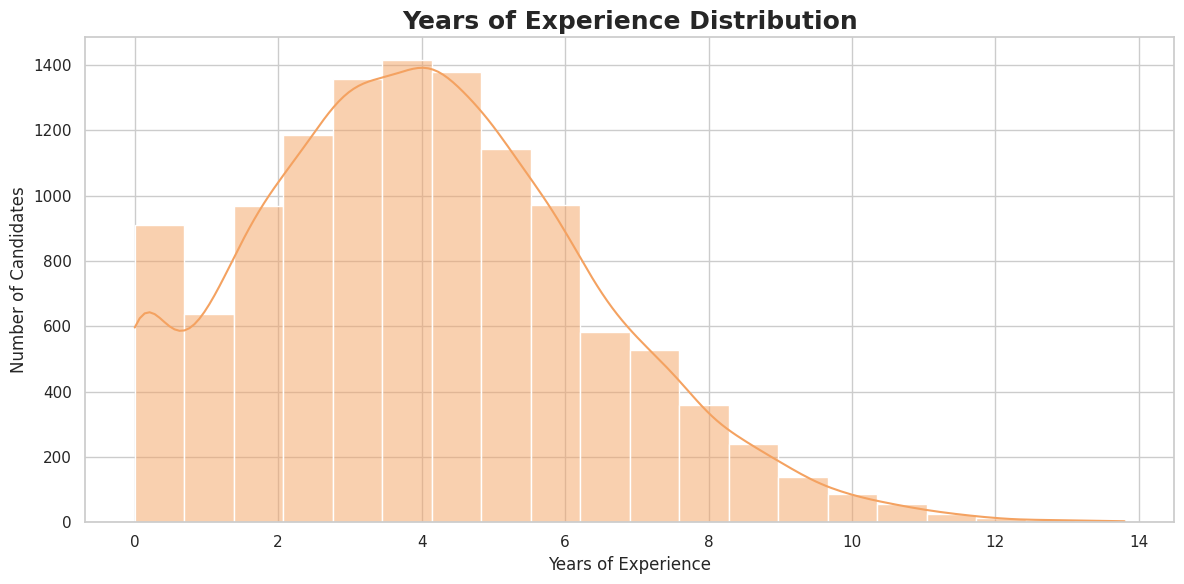

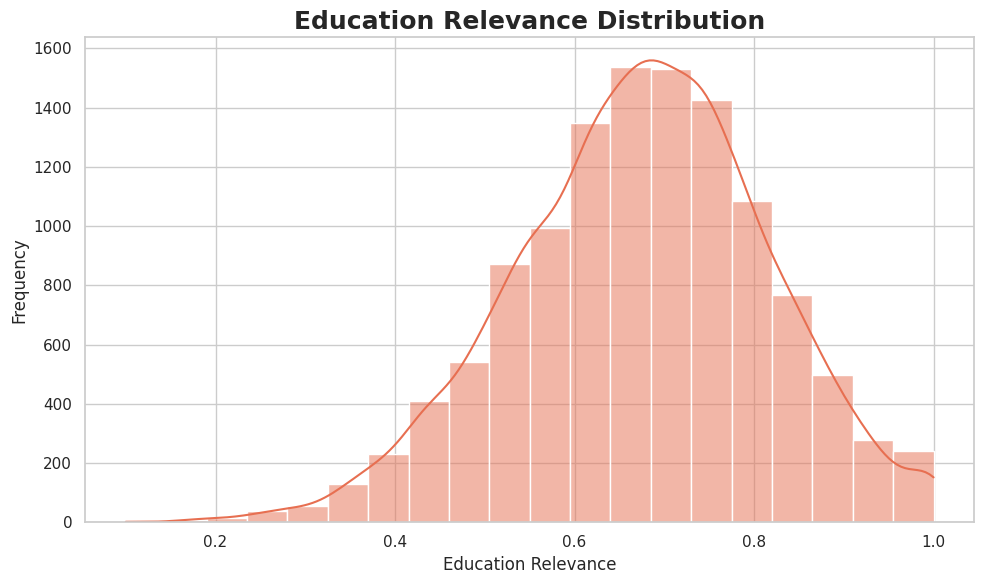

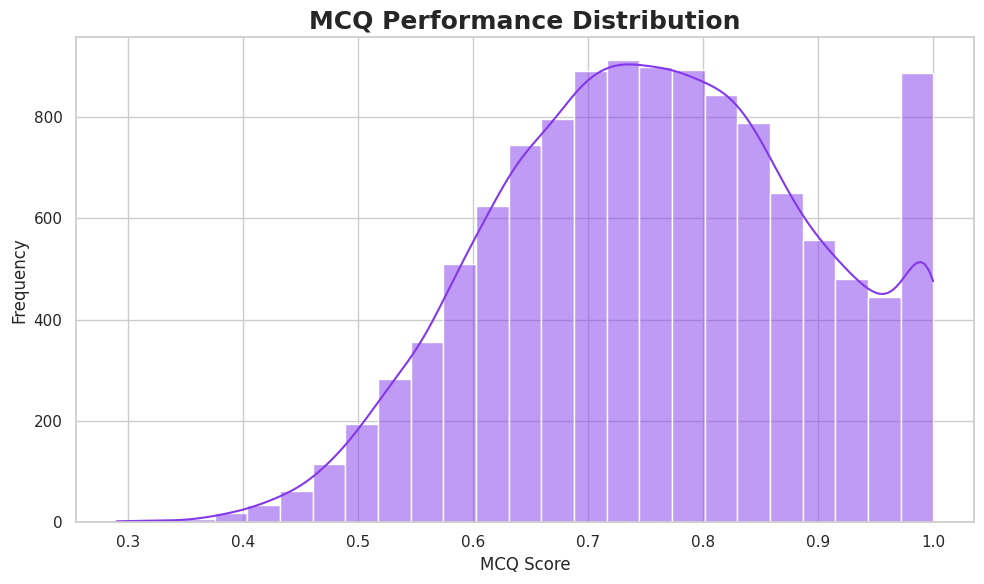

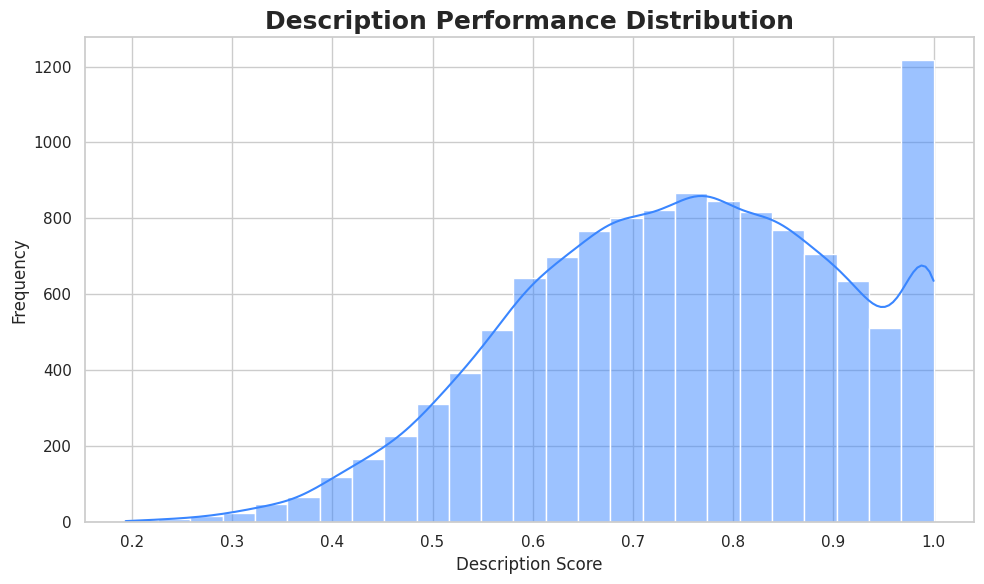

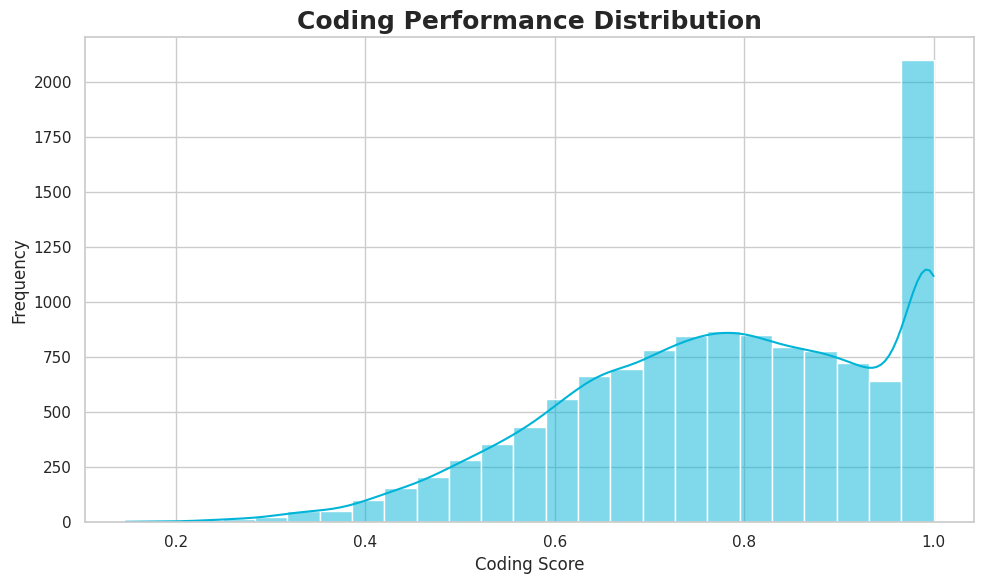

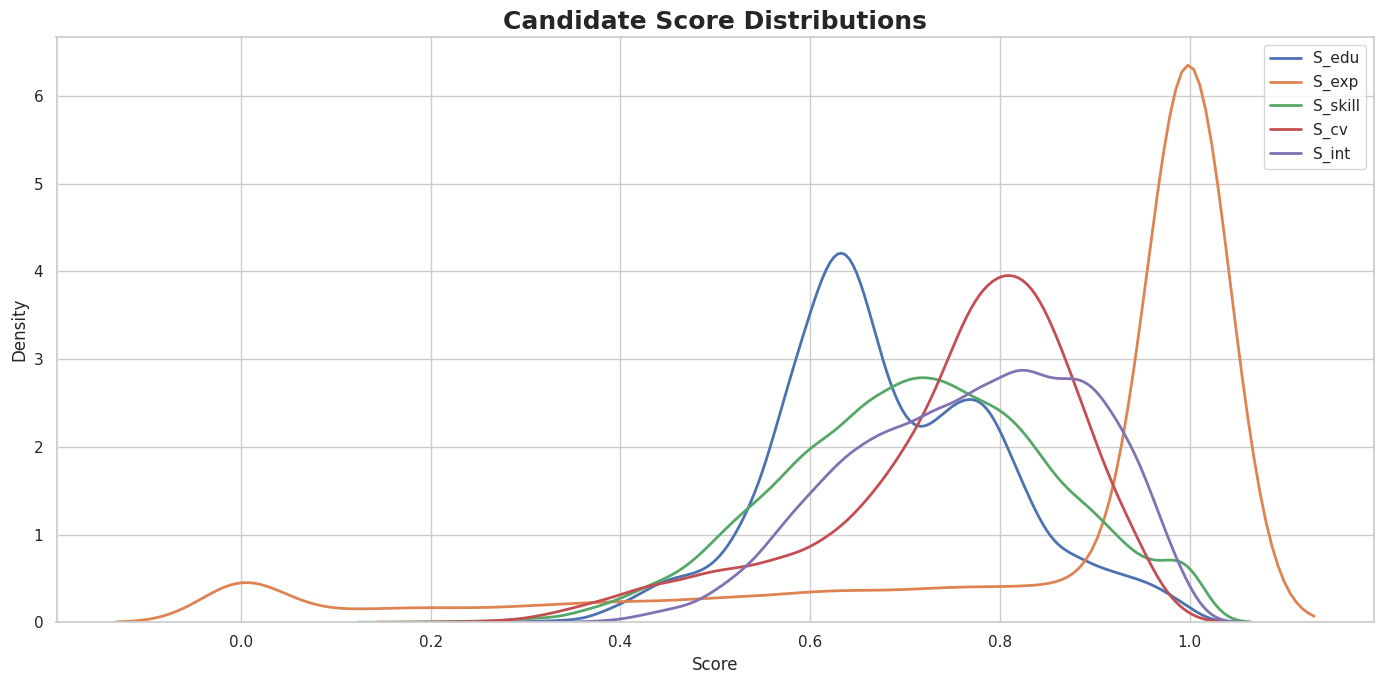

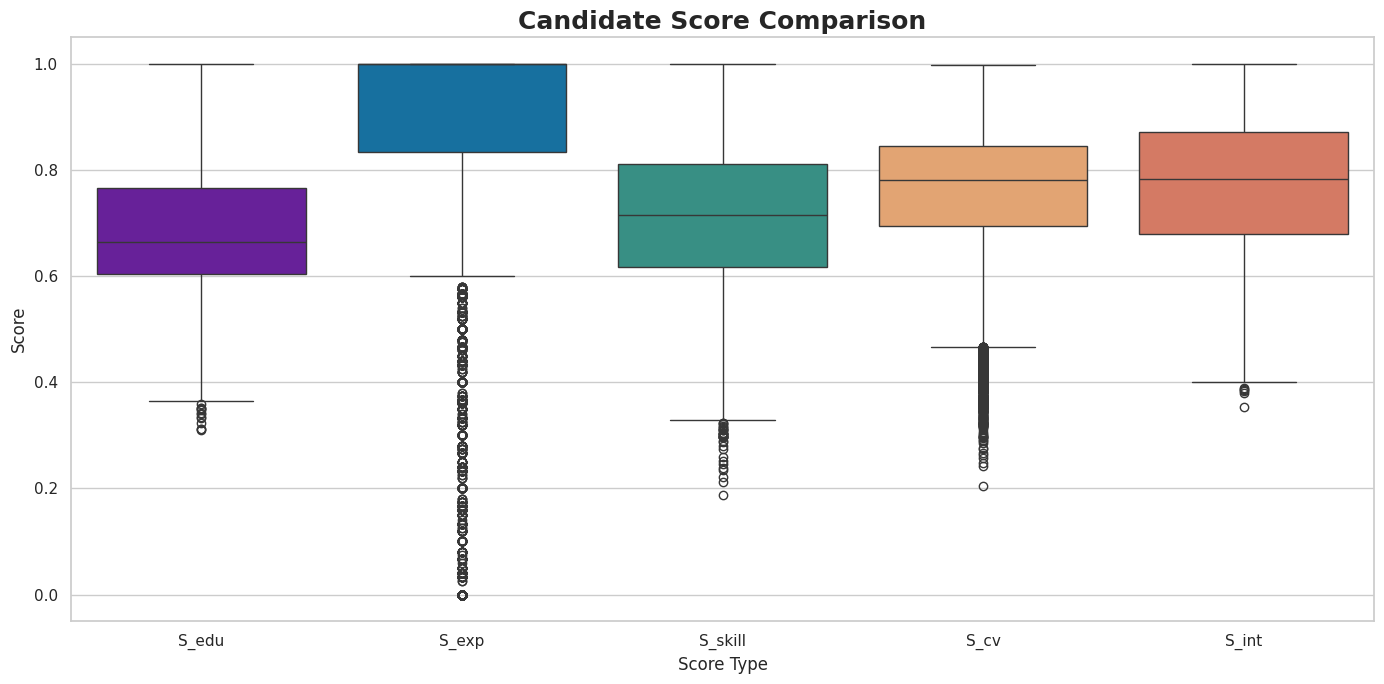

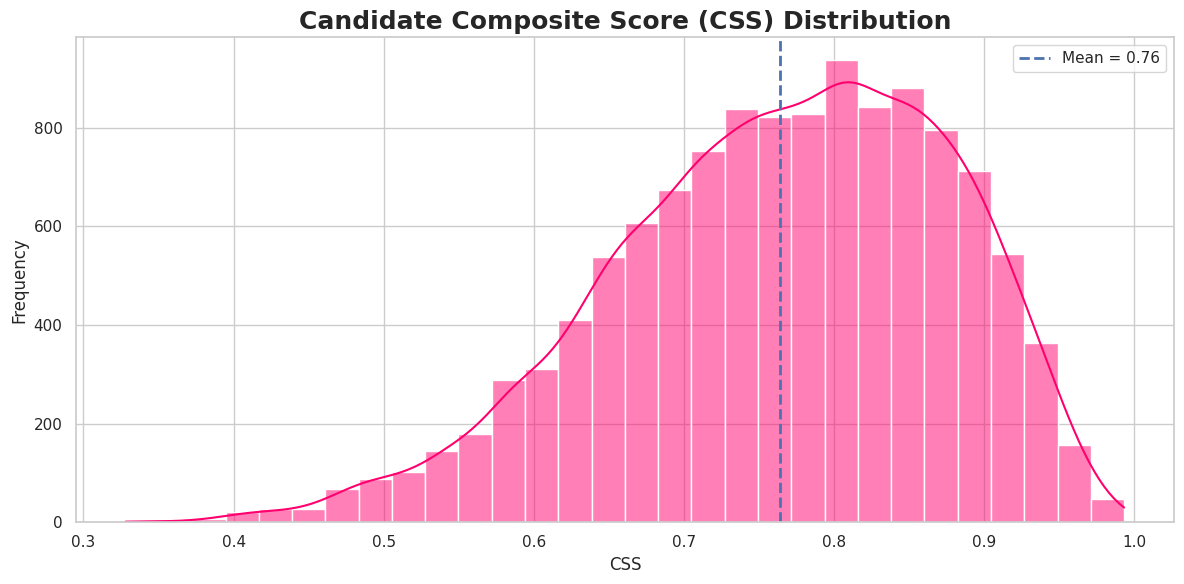

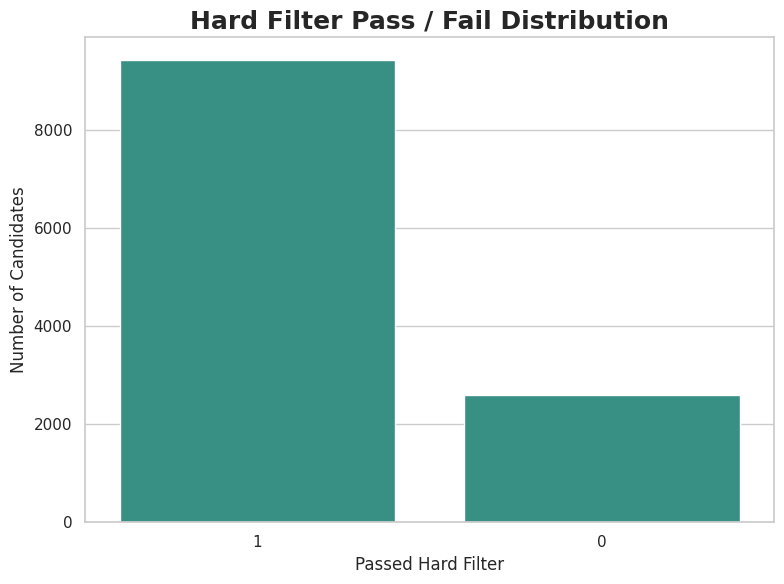

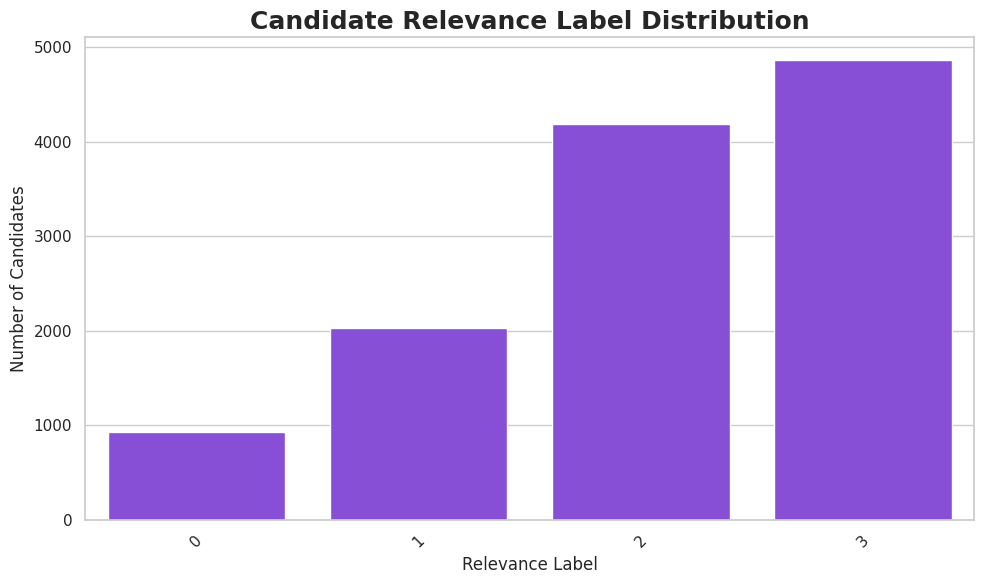

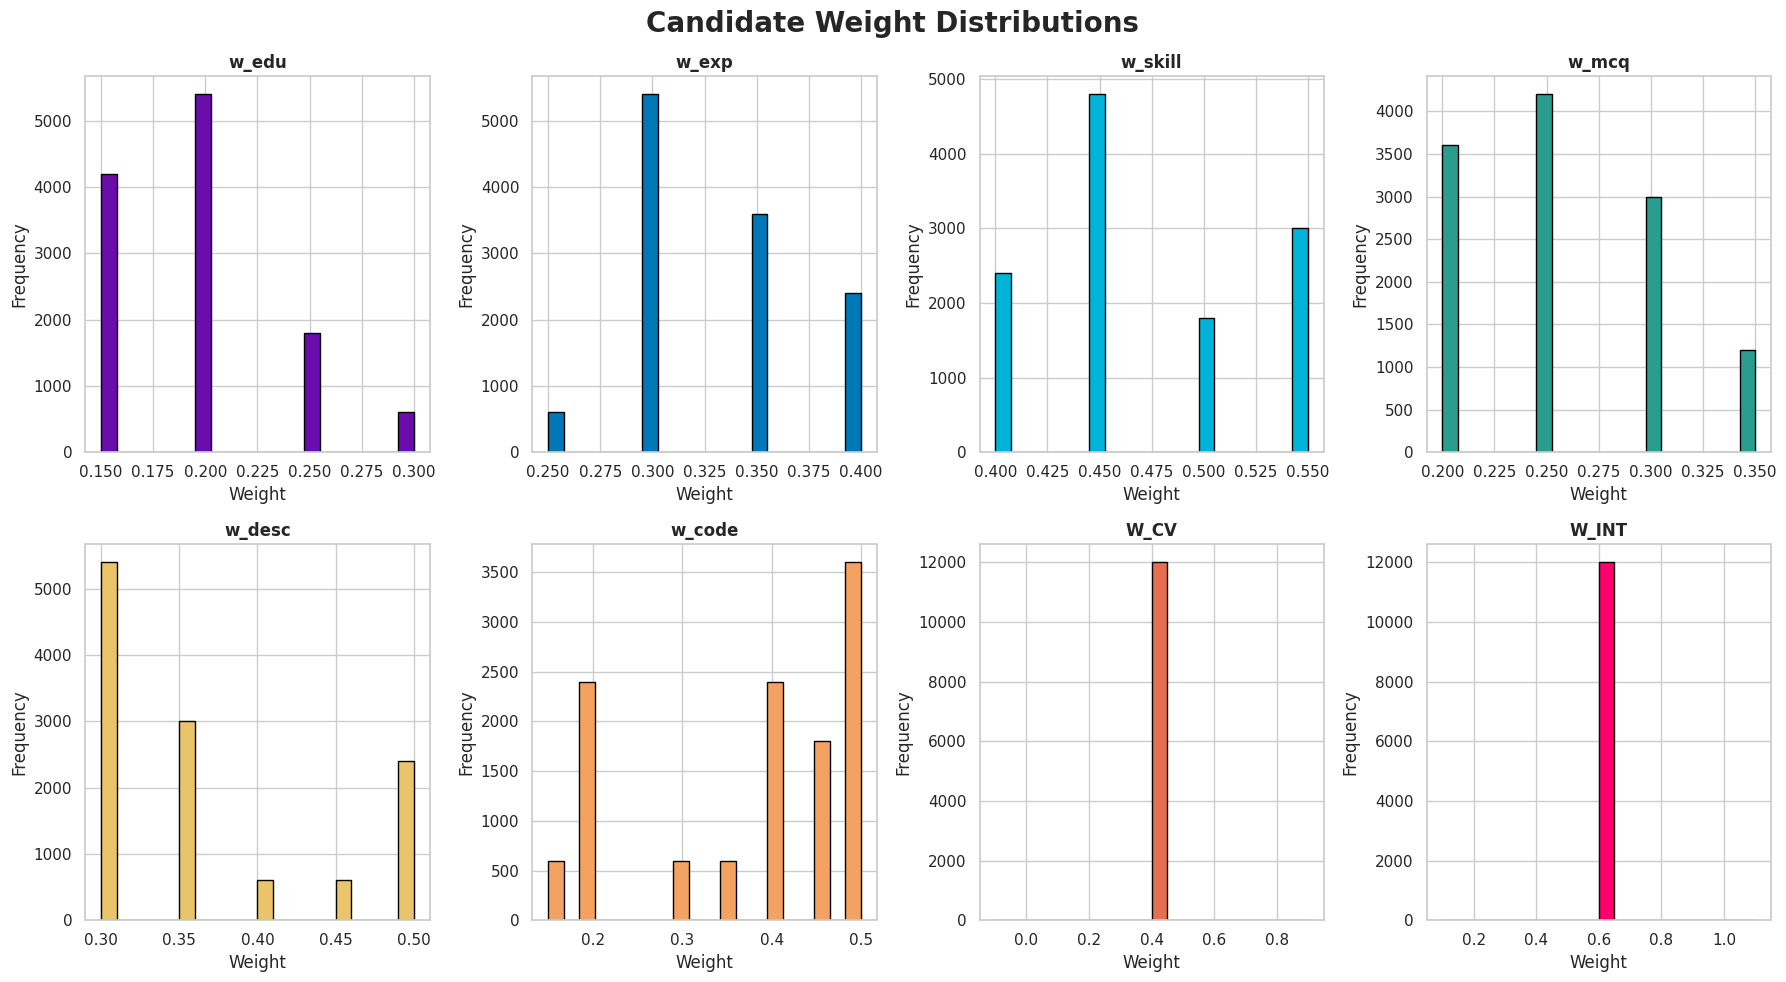

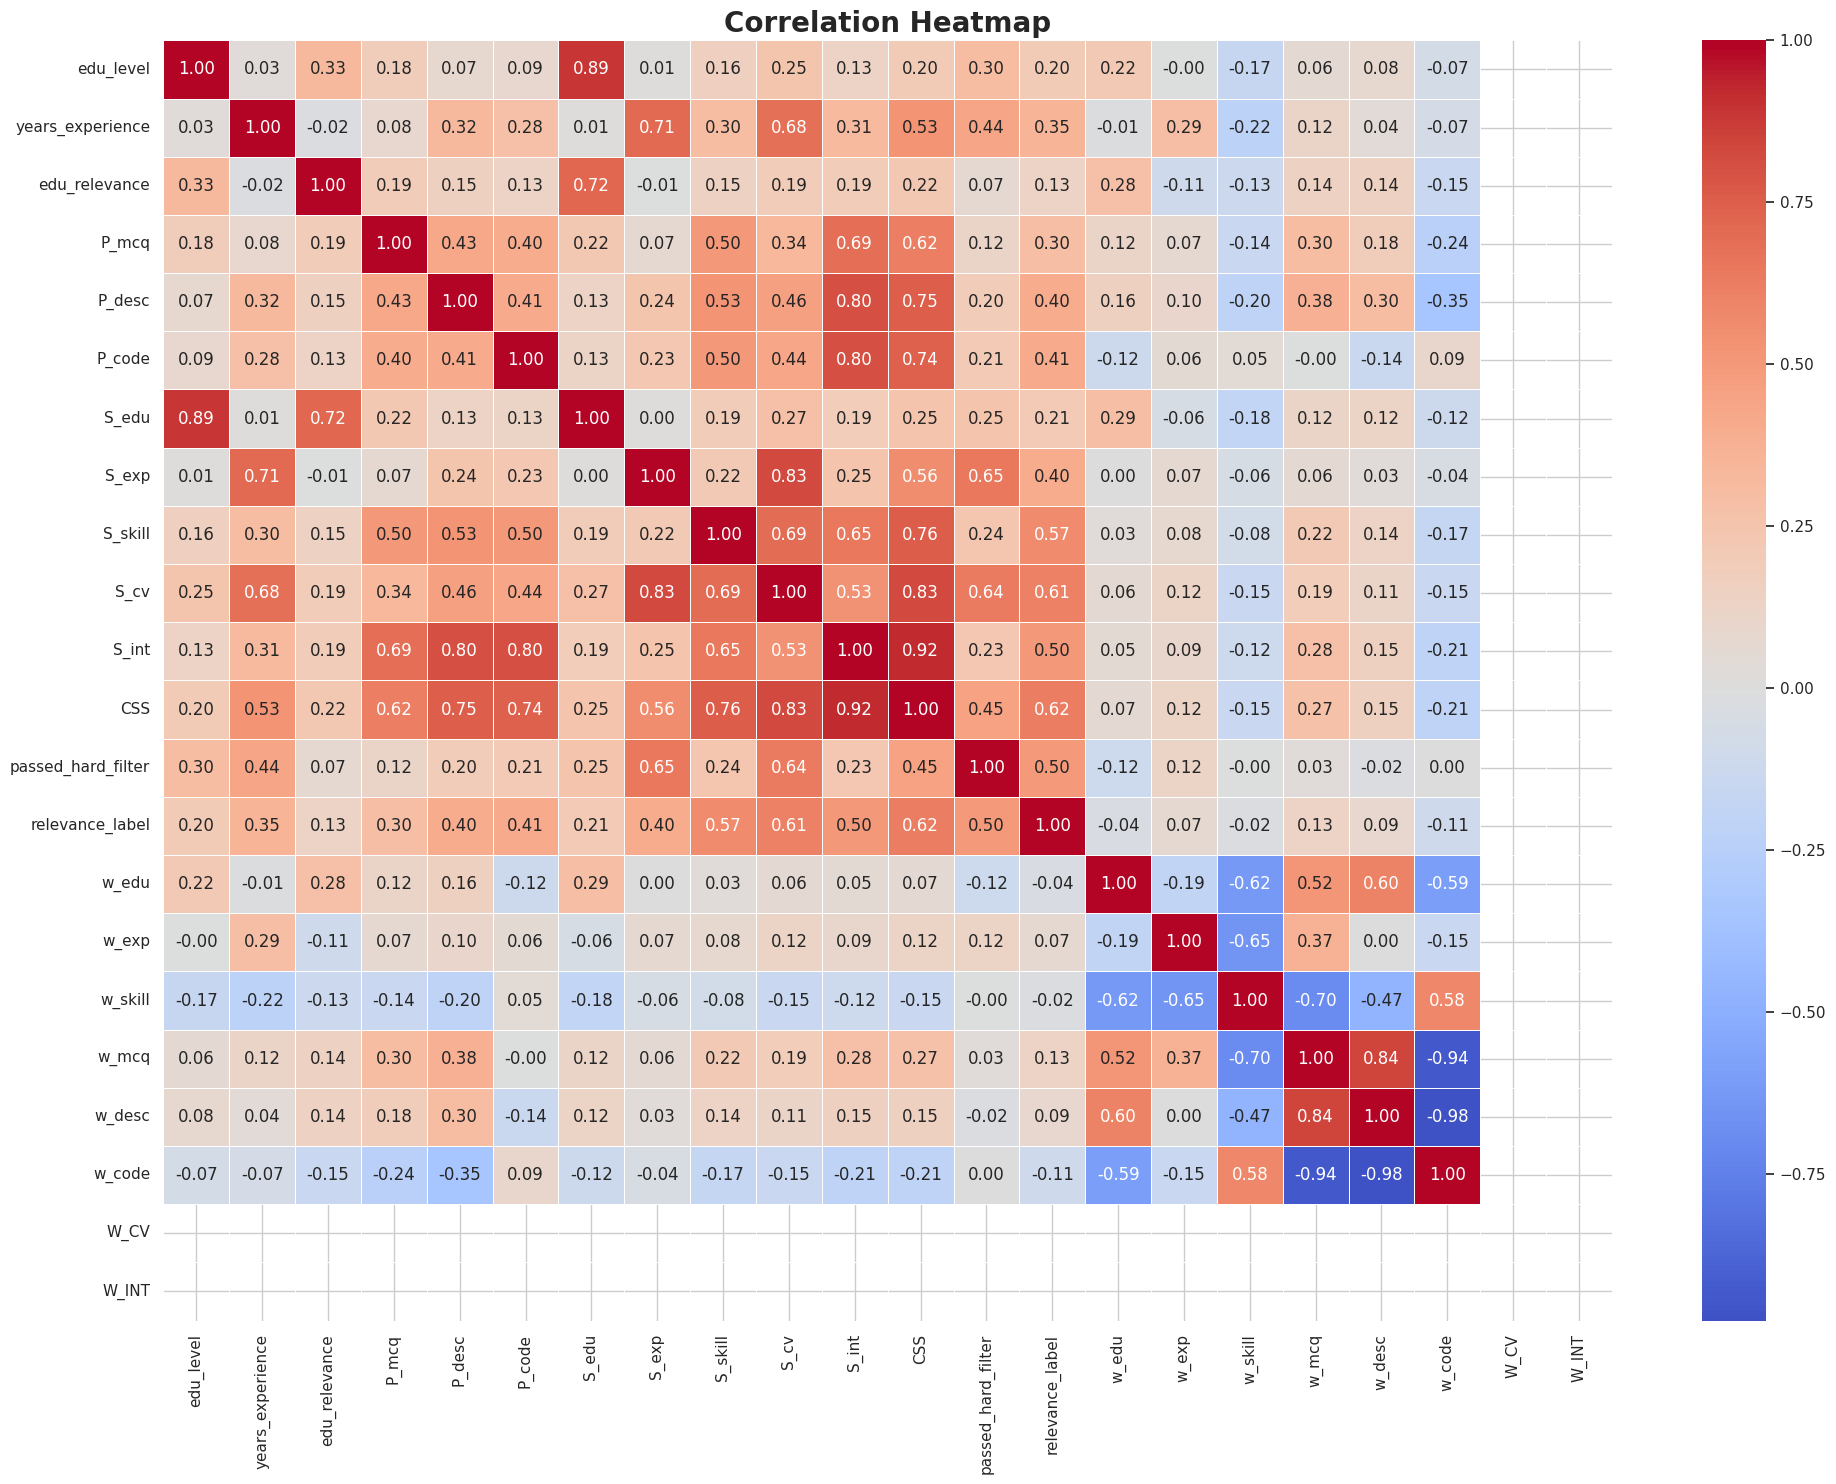

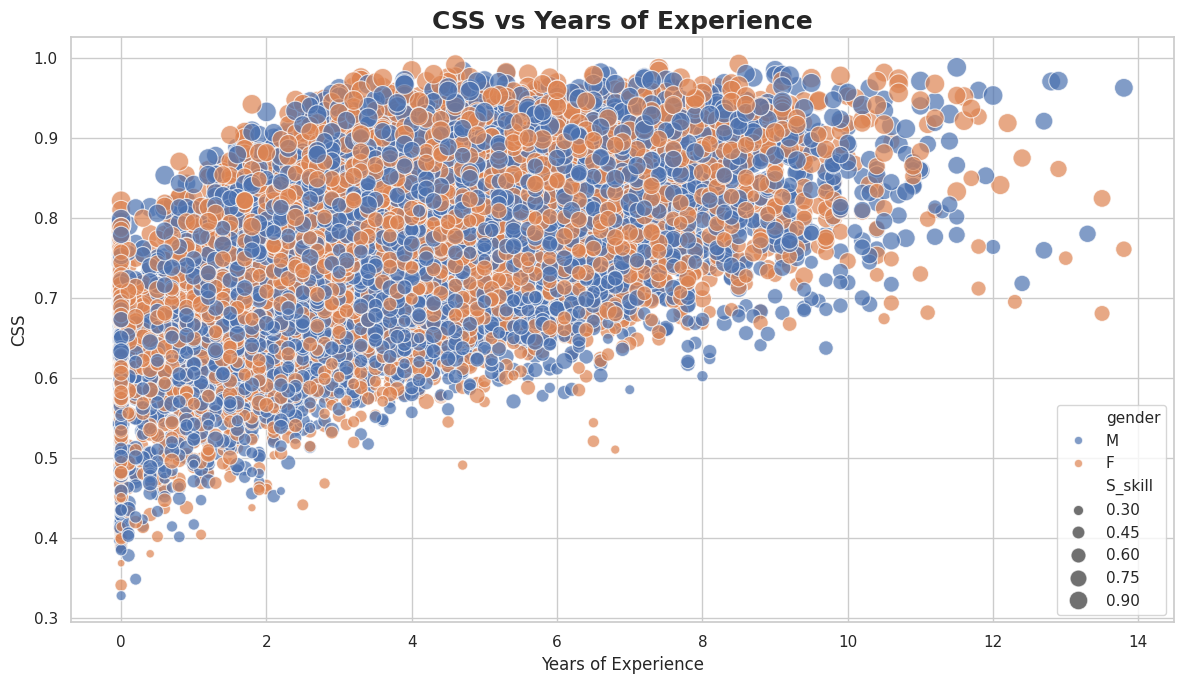

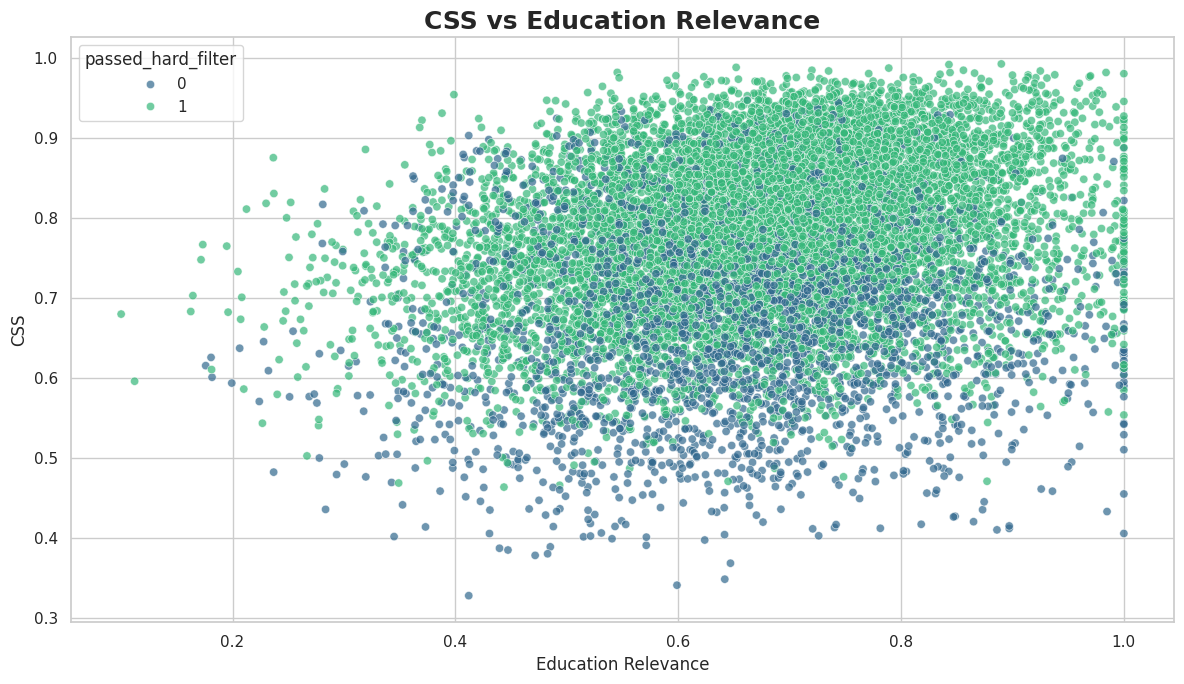

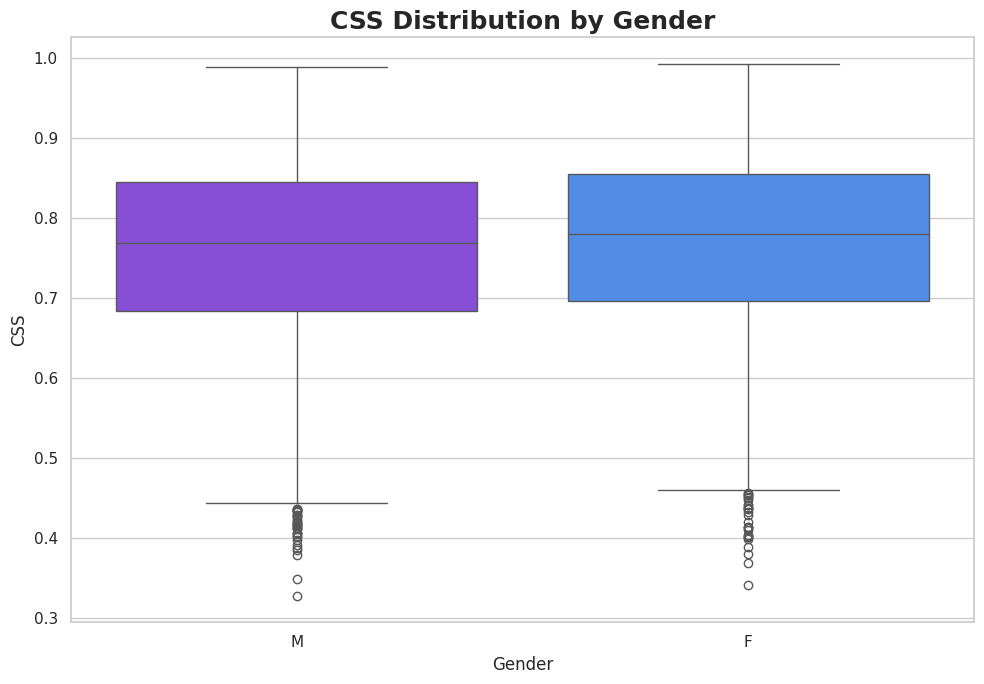

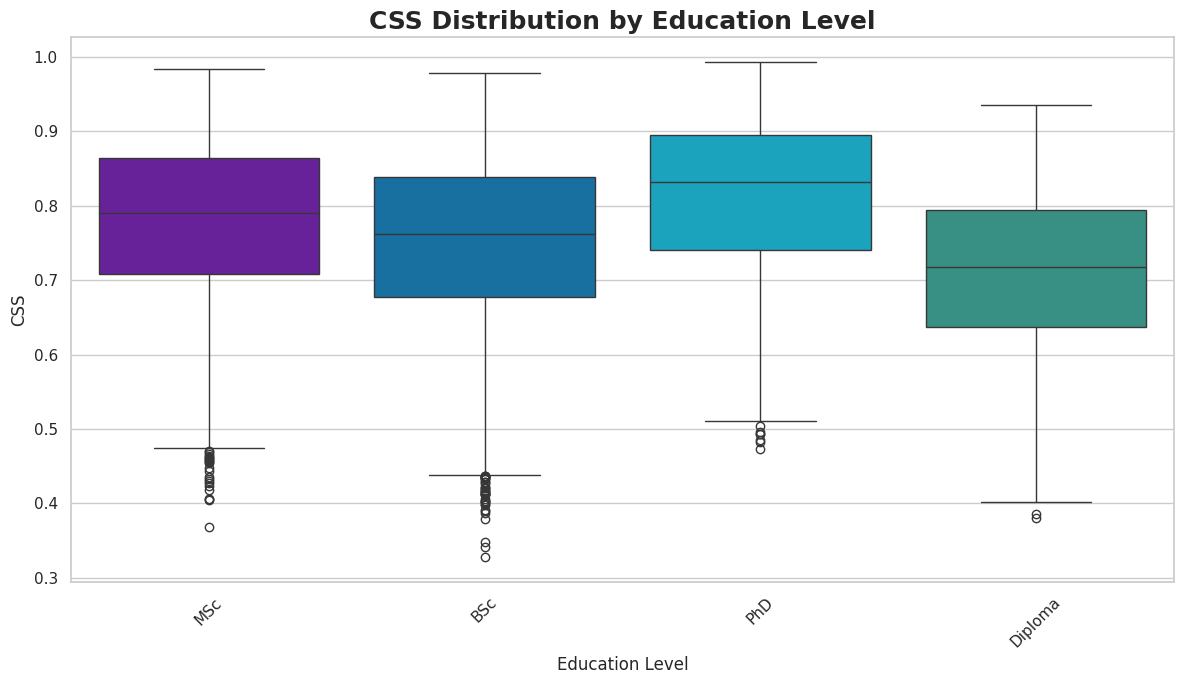

<Figure size 1200x700 with 0 Axes>

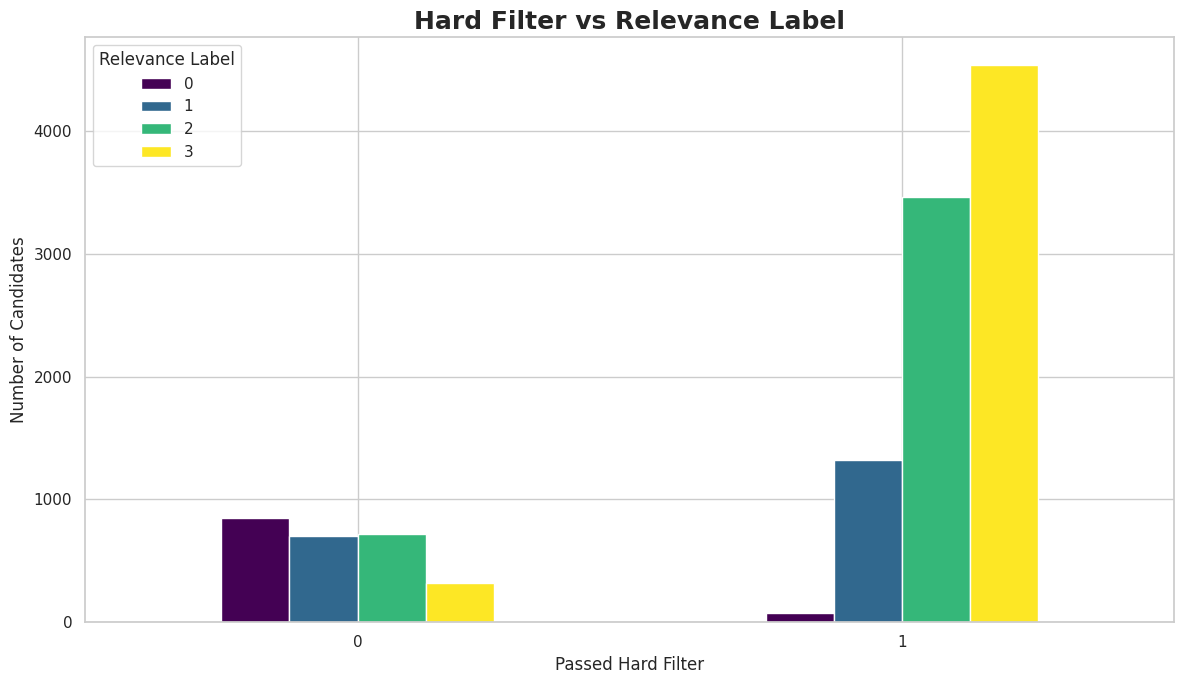

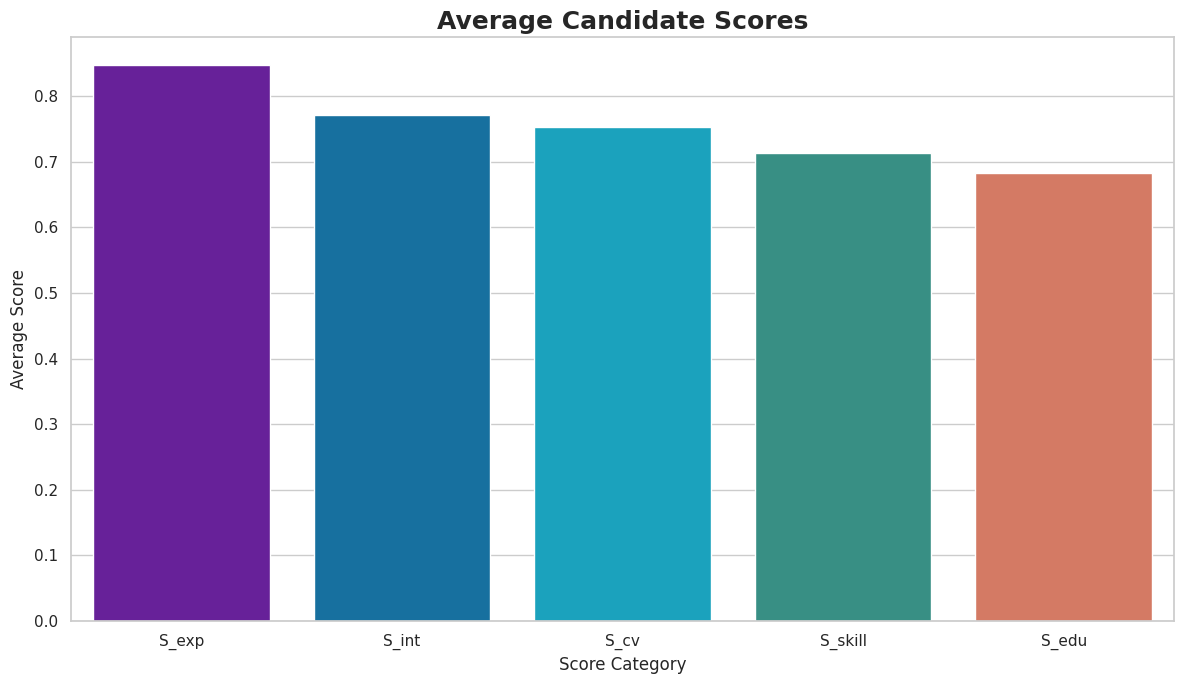

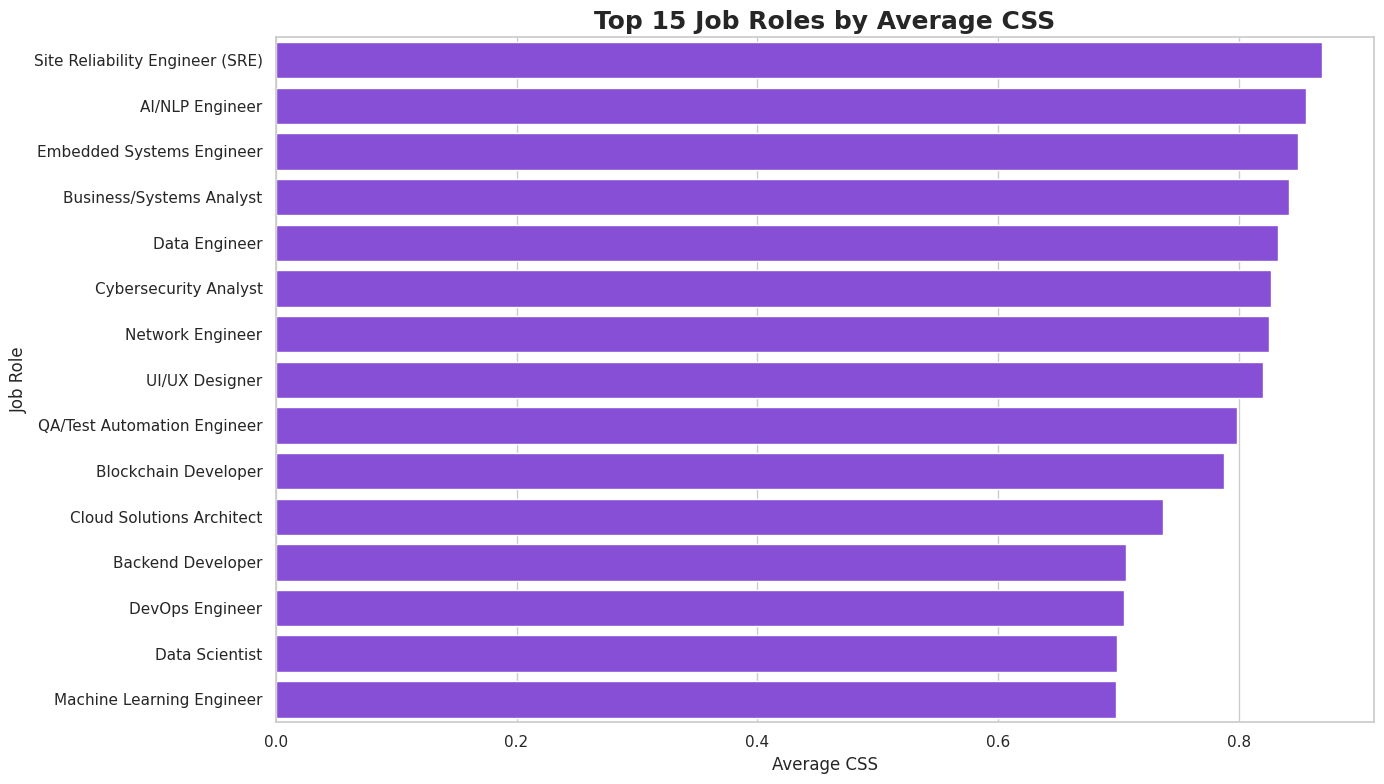

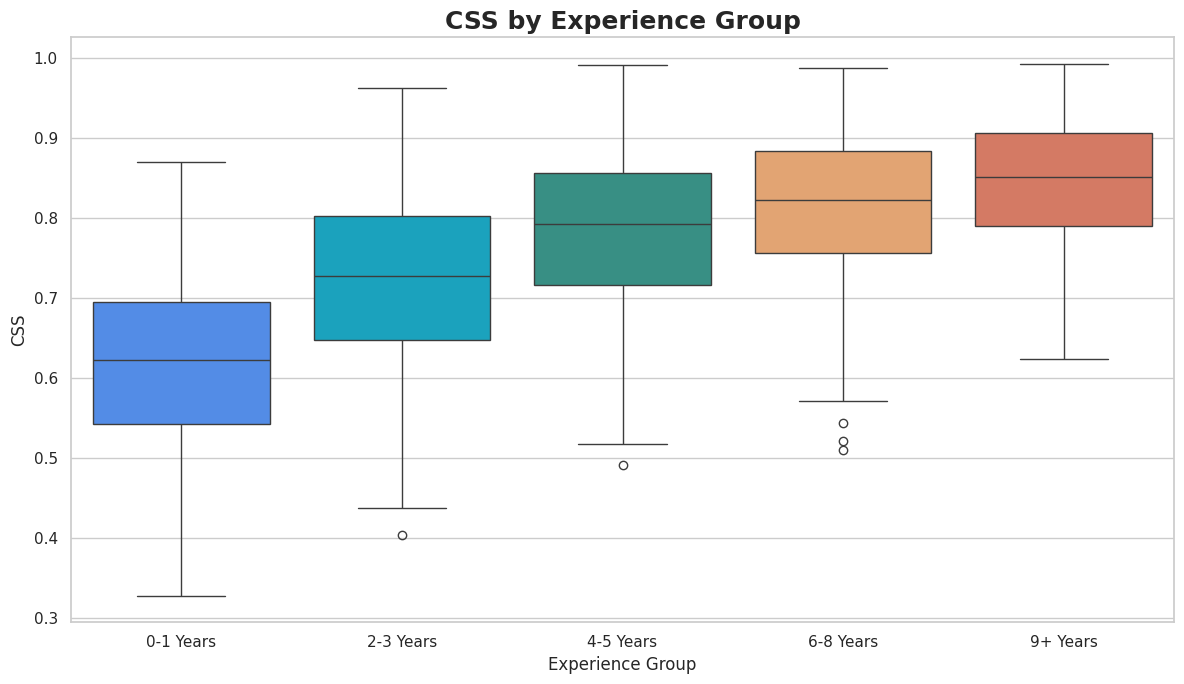

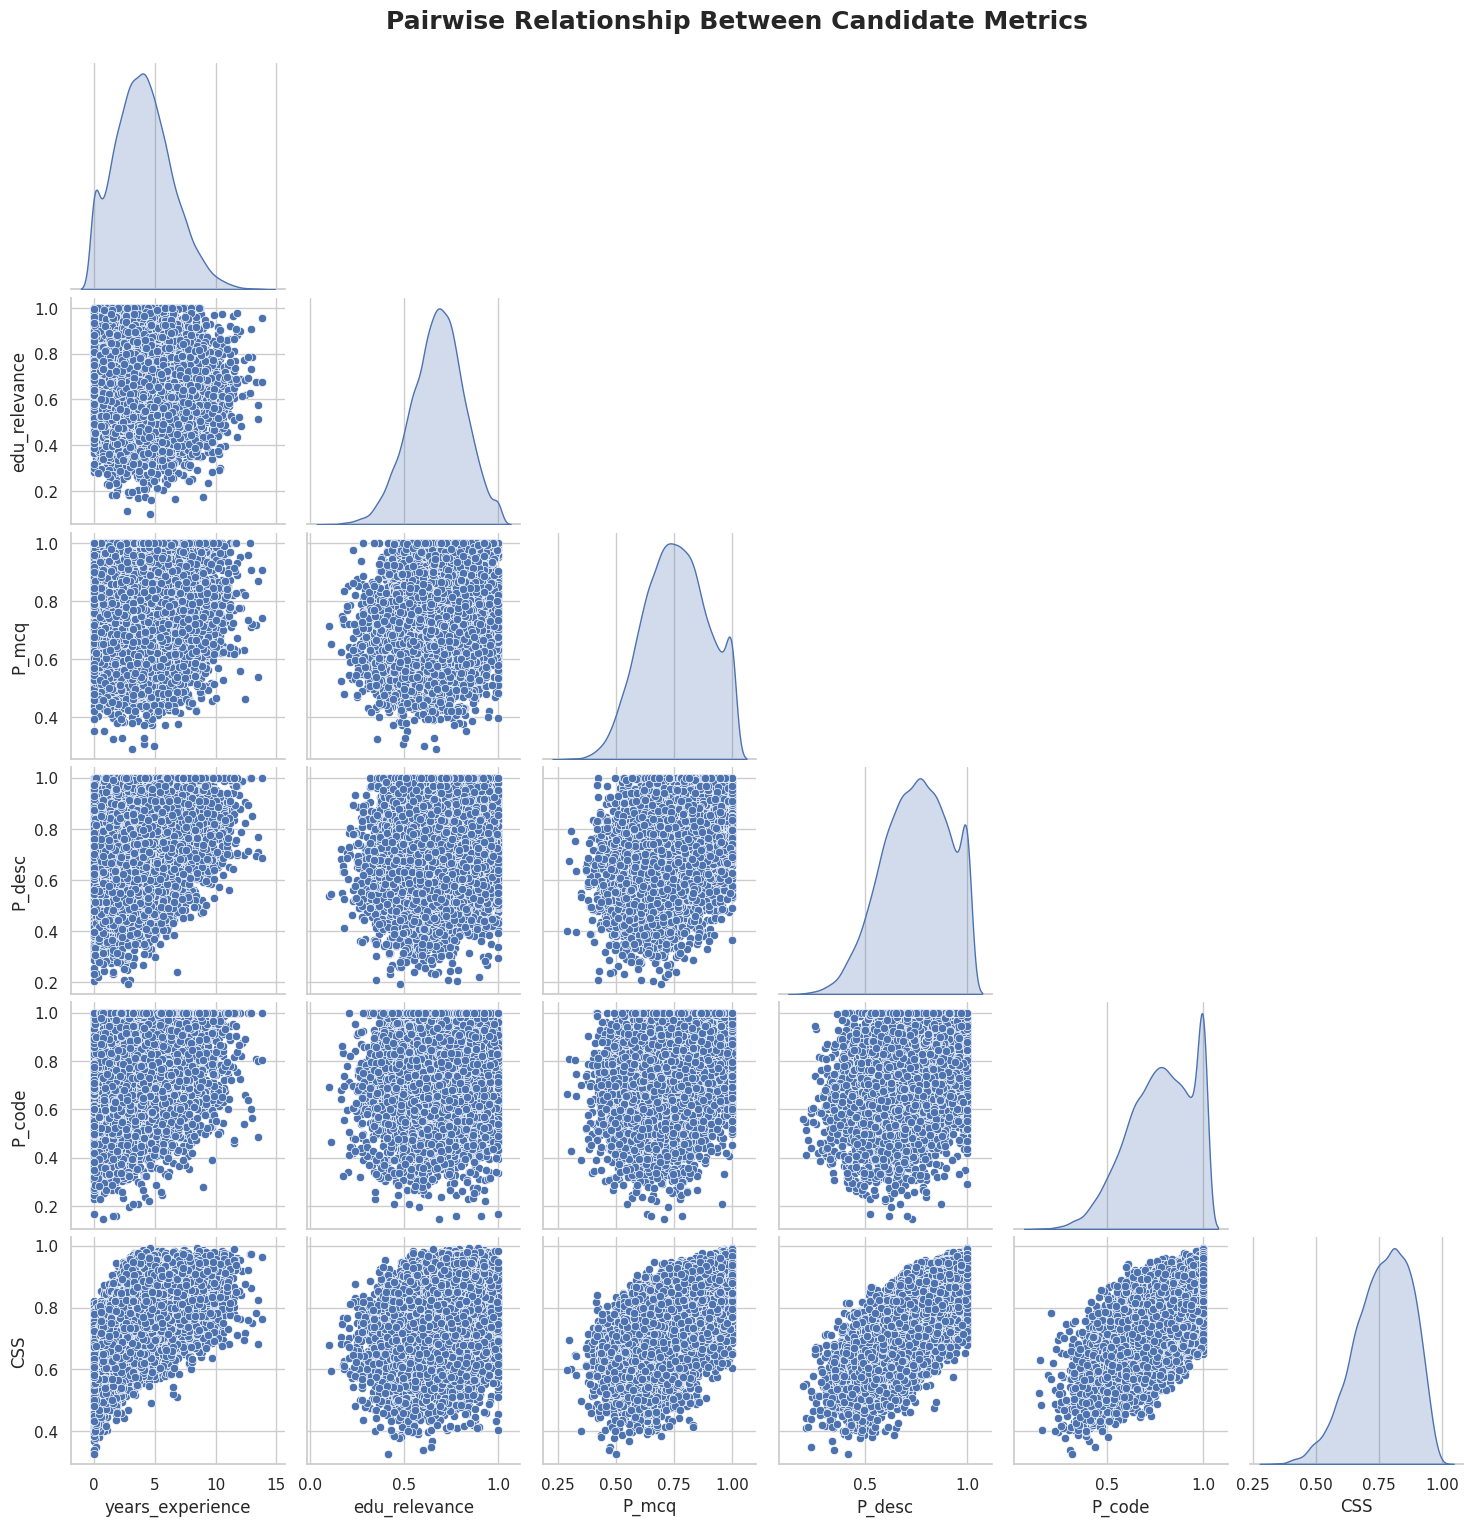


TOP 20 CANDIDATES BY CSS
      candidate_id                 job_role_display gender  years_experience  \
2868      CYB00469            Cybersecurity Analyst      F               8.5   
10637     AI_00438                  AI/NLP Engineer      F               4.6   
11423     EMB00024        Embedded Systems Engineer      M              11.5   
7202      DAT00003                    Data Engineer      F               7.4   
2991      CYB00592            Cybersecurity Analyst      F               4.0   
7296      DAT00097                    Data Engineer      M               9.0   
7781      DAT00582                    Data Engineer      F               7.4   
2616      CYB00217            Cybersecurity Analyst      M               4.7   
5027       BE00228                Backend Developer      F               5.3   
9849      BUS00250         Business/Systems Analyst      M               6.6   
8087      SIT00288  Site Reliability Engineer (SRE)      F              10.5   
2529      CYB0



FINAL DATASET SUMMARY
Total Candidates       : 12000
Total Features         : 29
Average Experience     : 4.04
Average CSS            : 0.76
Maximum CSS            : 0.99
Minimum CSS            : 0.33
Hard Filter Pass Rate  : 78.4 %

Top Job Role:
job_role_display
Software Engineer    600
Name: count, dtype: int64

Most Common Education Level:
edu_level_name
BSc    6389
Name: count, dtype: int64

Most Common Gender:
gender
M    6489
Name: count, dtype: int64

Visualization completed successfully!


In [13]:
# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option("display.max_columns", None)


print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
print(df.dtypes)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

# Missing-value percentage
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

print("\nMissing Percentage:")
print(missing_percentage)


# ============================================================
# 4. DUPLICATE RECORDS
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)

print("Number of duplicates:", df.duplicated().sum())


# ============================================================
# 5. STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("NUMERICAL SUMMARY")
print("=" * 70)

print(df.describe().T)


# ============================================================
# 6. SET COLOR PALETTE
# ============================================================

colors = [
    "#6A0DAD",
    "#0077B6",
    "#00B4D8",
    "#2A9D8F",
    "#E9C46A",
    "#F4A261",
    "#E76F51",
    "#8338EC",
    "#3A86FF",
    "#FF006E"
]

sns.set_theme(style="whitegrid")


# ============================================================
# 7. MISSING VALUES VISUALIZATION
# ============================================================

missing_plot = missing[missing > 0]

if len(missing_plot) > 0:

    plt.figure(figsize=(14, 6))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot.values,
        color="#E76F51"
    )

    plt.title(
        "Missing Values by Column",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=75)

    plt.tight_layout()
    plt.show()

else:
    print("No missing values found.")


# ============================================================
# 8. GENDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

gender_counts = df["gender"].value_counts()

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#8338EC", "#3A86FF", "#FF006E", "#2A9D8F"]
)

plt.title(
    "Gender Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.show()


# ============================================================
# 9. AGE GROUP DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="age_group",
    color="#00B4D8"
)

plt.title(
    "Candidate Age Group Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Number of Candidates")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 10. JOB ROLE DISTRIBUTION
# ============================================================

job_counts = (
    df["job_role_display"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=job_counts.values,
    y=job_counts.index,
    color="#6A0DAD"
)

plt.title(
    "Top 15 Job Roles",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Candidates")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()


# ============================================================
# 11. EDUCATION LEVEL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

edu_counts = df["edu_level_name"].value_counts()

sns.barplot(
    x=edu_counts.index,
    y=edu_counts.values,
    color="#2A9D8F"
)

plt.title(
    "Education Level Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Education Level")
plt.ylabel("Number of Candidates")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 12. YEARS OF EXPERIENCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["years_experience"],
    bins=20,
    kde=True,
    color="#F4A261"
)

plt.title(
    "Years of Experience Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Years of Experience")
plt.ylabel("Number of Candidates")

plt.tight_layout()
plt.show()


# ============================================================
# 13. EDUCATION RELEVANCE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["edu_relevance"],
    bins=20,
    kde=True,
    color="#E76F51"
)

plt.title(
    "Education Relevance Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Education Relevance")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 14. MCQ SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["P_mcq"],
    bins=25,
    kde=True,
    color="#8338EC"
)

plt.title(
    "MCQ Performance Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("MCQ Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 15. DESCRIPTION SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["P_desc"],
    bins=25,
    kde=True,
    color="#3A86FF"
)

plt.title(
    "Description Performance Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Description Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 16. CODING SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["P_code"],
    bins=25,
    kde=True,
    color="#00B4D8"
)

plt.title(
    "Coding Performance Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Coding Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 17. CANDIDATE SCORE DISTRIBUTIONS
# ============================================================

score_columns = [
    "S_edu",
    "S_exp",
    "S_skill",
    "S_cv",
    "S_int"
]

plt.figure(figsize=(14, 7))

for i, column in enumerate(score_columns):

    sns.kdeplot(
        data=df,
        x=column,
        label=column,
        linewidth=2
    )

plt.title(
    "Candidate Score Distributions",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Score")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 18. SCORE BOXPLOT
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[score_columns],
    palette=[
        "#6A0DAD",
        "#0077B6",
        "#2A9D8F",
        "#F4A261",
        "#E76F51"
    ]
)

plt.title(
    "Candidate Score Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Score Type")
plt.ylabel("Score")

plt.xticks(
    range(len(score_columns)),
    score_columns
)

plt.tight_layout()
plt.show()


# ============================================================
# 19. CSS DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["CSS"],
    bins=30,
    kde=True,
    color="#FF006E"
)

plt.axvline(
    df["CSS"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['CSS'].mean():.2f}"
)

plt.title(
    "Candidate Composite Score (CSS) Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("CSS")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 20. HARD FILTER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

hard_filter_counts = (
    df["passed_hard_filter"]
    .value_counts()
)

sns.barplot(
    x=hard_filter_counts.index.astype(str),
    y=hard_filter_counts.values,
    color="#2A9D8F"
)

plt.title(
    "Hard Filter Pass / Fail Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Passed Hard Filter")
plt.ylabel("Number of Candidates")

plt.tight_layout()
plt.show()


# ============================================================
# 21. RELEVANCE LABEL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

relevance_counts = (
    df["relevance_label"]
    .value_counts()
)

sns.barplot(
    x=relevance_counts.index,
    y=relevance_counts.values,
    color="#8338EC"
)

plt.title(
    "Candidate Relevance Label Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Relevance Label")
plt.ylabel("Number of Candidates")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 22. WEIGHT DISTRIBUTION
# ============================================================

weight_columns = [
    "w_edu",
    "w_exp",
    "w_skill",
    "w_mcq",
    "w_desc",
    "w_code",
    "W_CV",
    "W_INT"
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 10)
)

axes = axes.flatten()

weight_colors = [
    "#6A0DAD",
    "#0077B6",
    "#00B4D8",
    "#2A9D8F",
    "#E9C46A",
    "#F4A261",
    "#E76F51",
    "#FF006E"
]

for i, column in enumerate(weight_columns):

    axes[i].hist(
        df[column].dropna(),
        bins=20,
        color=weight_colors[i],
        edgecolor="black"
    )

    axes[i].set_title(
        column,
        fontweight="bold"
    )

    axes[i].set_xlabel("Weight")
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Candidate Weight Distributions",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 23. CORRELATION HEATMAP
# ============================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation = df[numeric_columns].corr()

plt.figure(figsize=(20, 15))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 24. CSS VS YEARS OF EXPERIENCE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="years_experience",
    y="CSS",
    hue="gender",
    size="S_skill",
    sizes=(30, 200),
    alpha=0.7
)

plt.title(
    "CSS vs Years of Experience",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Years of Experience")
plt.ylabel("CSS")

plt.tight_layout()
plt.show()


# ============================================================
# 25. CSS VS EDUCATION RELEVANCE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="edu_relevance",
    y="CSS",
    hue="passed_hard_filter",
    palette="viridis",
    alpha=0.7
)

plt.title(
    "CSS vs Education Relevance",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Education Relevance")
plt.ylabel("CSS")

plt.tight_layout()
plt.show()


# ============================================================
# 26. CSS BY GENDER
# ============================================================

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x="gender",
    y="CSS",
    palette=[
        "#8338EC",
        "#3A86FF",
        "#FF006E",
        "#2A9D8F"
    ]
)

plt.title(
    "CSS Distribution by Gender",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("CSS")

plt.tight_layout()
plt.show()


# ============================================================
# 27. CSS BY EDUCATION LEVEL
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="edu_level_name",
    y="CSS",
    palette=[
        "#6A0DAD",
        "#0077B6",
        "#00B4D8",
        "#2A9D8F",
        "#E9C46A",
        "#F4A261"
    ]
)

plt.title(
    "CSS Distribution by Education Level",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Education Level")
plt.ylabel("CSS")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 28. HARD FILTER VS RELEVANCE LABEL
# ============================================================

plt.figure(figsize=(12, 7))

cross_table = pd.crosstab(
    df["passed_hard_filter"],
    df["relevance_label"]
)

cross_table.plot(
    kind="bar",
    figsize=(12, 7),
    colormap="viridis"
)

plt.title(
    "Hard Filter vs Relevance Label",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Passed Hard Filter")
plt.ylabel("Number of Candidates")

plt.xticks(rotation=0)
plt.legend(title="Relevance Label")

plt.tight_layout()
plt.show()


# ============================================================
# 29. AVERAGE SCORES
# ============================================================

average_scores = df[
    score_columns
].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=average_scores.index,
    y=average_scores.values,
    palette=[
        "#6A0DAD",
        "#0077B6",
        "#00B4D8",
        "#2A9D8F",
        "#E76F51"
    ]
)

plt.title(
    "Average Candidate Scores",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Score Category")
plt.ylabel("Average Score")

plt.tight_layout()
plt.show()


# ============================================================
# 30. TOP JOB ROLES BY AVERAGE CSS
# ============================================================

top_roles_css = (
    df.groupby("job_role_display")["CSS"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14, 8))

sns.barplot(
    x=top_roles_css.values,
    y=top_roles_css.index,
    color="#8338EC"
)

plt.title(
    "Top 15 Job Roles by Average CSS",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average CSS")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()


# ============================================================
# 31. EXPERIENCE GROUP VS CSS
# ============================================================

df["experience_group"] = pd.cut(
    df["years_experience"],
    bins=[
        -1,
        1,
        3,
        5,
        8,
        100
    ],
    labels=[
        "0-1 Years",
        "2-3 Years",
        "4-5 Years",
        "6-8 Years",
        "9+ Years"
    ]
)

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="experience_group",
    y="CSS",
    palette=[
        "#3A86FF",
        "#00B4D8",
        "#2A9D8F",
        "#F4A261",
        "#E76F51"
    ]
)

plt.title(
    "CSS by Experience Group",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Experience Group")
plt.ylabel("CSS")

plt.tight_layout()
plt.show()


# ============================================================
# 32. PAIRPLOT OF IMPORTANT NUMERICAL VARIABLES
# ============================================================

pair_columns = [
    "years_experience",
    "edu_relevance",
    "P_mcq",
    "P_desc",
    "P_code",
    "CSS"
]

pair_data = df[pair_columns].dropna()

sns.pairplot(
    pair_data,
    diag_kind="kde",
    corner=True
)

plt.suptitle(
    "Pairwise Relationship Between Candidate Metrics",
    y=1.02,
    fontsize=18,
    fontweight="bold"
)

plt.show()


# ============================================================
# 33. TOP CANDIDATES BY CSS
# ============================================================

top_candidates = (
    df.sort_values(
        by="CSS",
        ascending=False
    )
    [
        [
            "candidate_id",
            "job_role_display",
            "gender",
            "years_experience",
            "CSS",
            "relevance_label"
        ]
    ]
    .head(20)
)

print("\n" + "=" * 70)
print("TOP 20 CANDIDATES BY CSS")
print("=" * 70)

print(top_candidates)


# ============================================================
# 34. INTERACTIVE PLOTLY VISUALIZATION
# ============================================================

fig = px.scatter(
    df,
    x="years_experience",
    y="CSS",
    color="relevance_label",
    size="S_skill",
    hover_data=[
        "candidate_id",
        "job_role_display",
        "gender",
        "edu_level_name",
        "years_experience"
    ],
    title="Interactive Candidate Experience vs CSS"
)

fig.update_layout(
    template="plotly_white",
    title_font_size=20
)

fig.show()


# ============================================================
# 35. INTERACTIVE JOB ROLE CHART
# ============================================================

job_role_plot = (
    df["job_role_display"]
    .value_counts()
    .head(20)
    .reset_index()
)

job_role_plot.columns = [
    "job_role",
    "candidate_count"
]

fig = px.bar(
    job_role_plot,
    x="candidate_count",
    y="job_role",
    orientation="h",
    color="candidate_count",
    color_continuous_scale="Viridis",
    title="Top 20 Job Roles by Candidate Count"
)

fig.update_layout(
    template="plotly_white"
)

fig.show()


# ============================================================
# 36. INTERACTIVE CSS DISTRIBUTION
# ============================================================

fig = px.histogram(
    df,
    x="CSS",
    nbins=30,
    color="relevance_label",
    title="CSS Distribution by Relevance Label",
    marginal="box"
)

fig.update_layout(
    template="plotly_white"
)

fig.show()


# ============================================================
# 37. FINAL DATASET SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

print("Total Candidates       :", len(df))
print("Total Features         :", len(df.columns))
print(
    "Average Experience     :",
    round(df["years_experience"].mean(), 2)
)
print(
    "Average CSS            :",
    round(df["CSS"].mean(), 2)
)
print(
    "Maximum CSS            :",
    round(df["CSS"].max(), 2)
)
print(
    "Minimum CSS            :",
    round(df["CSS"].min(), 2)
)

print(
    "Hard Filter Pass Rate  :",
    round(
        df["passed_hard_filter"].mean() * 100,
        2
    ),
    "%"
)

print("\nTop Job Role:")

print(
    df["job_role_display"]
    .value_counts()
    .head(1)
)

print("\nMost Common Education Level:")

print(
    df["edu_level_name"]
    .value_counts()
    .head(1)
)

print("\nMost Common Gender:")

print(
    df["gender"]
    .value_counts()
    .head(1)
)

print("\nVisualization completed successfully!")

## Feature engineering


TARGET DISTRIBUTION
relevance_label
3    4861
2    4183
1    2028
0     928
Name: count, dtype: int64

Columns after removing unnecessary columns:
['job_role', 'gender', 'age_group', 'edu_level', 'years_experience', 'edu_relevance', 'P_mcq', 'P_desc', 'P_code', 'S_edu', 'S_exp', 'S_skill', 'S_cv', 'S_int', 'CSS', 'passed_hard_filter', 'relevance_label', 'w_edu', 'w_exp', 'w_skill', 'w_mcq', 'w_desc', 'w_code', 'W_CV', 'W_INT', 'experience_group']

MISSING VALUES BEFORE PROCESSING
job_role              0
gender                0
age_group             0
edu_level             0
years_experience      0
edu_relevance         0
P_mcq                 0
P_desc                0
P_code                0
S_edu                 0
S_exp                 0
S_skill               0
S_cv                  0
S_int                 0
CSS                   0
passed_hard_filter    0
relevance_label       0
w_edu                 0
w_exp                 0
w_skill               0
w_mcq                 0
w_desc    

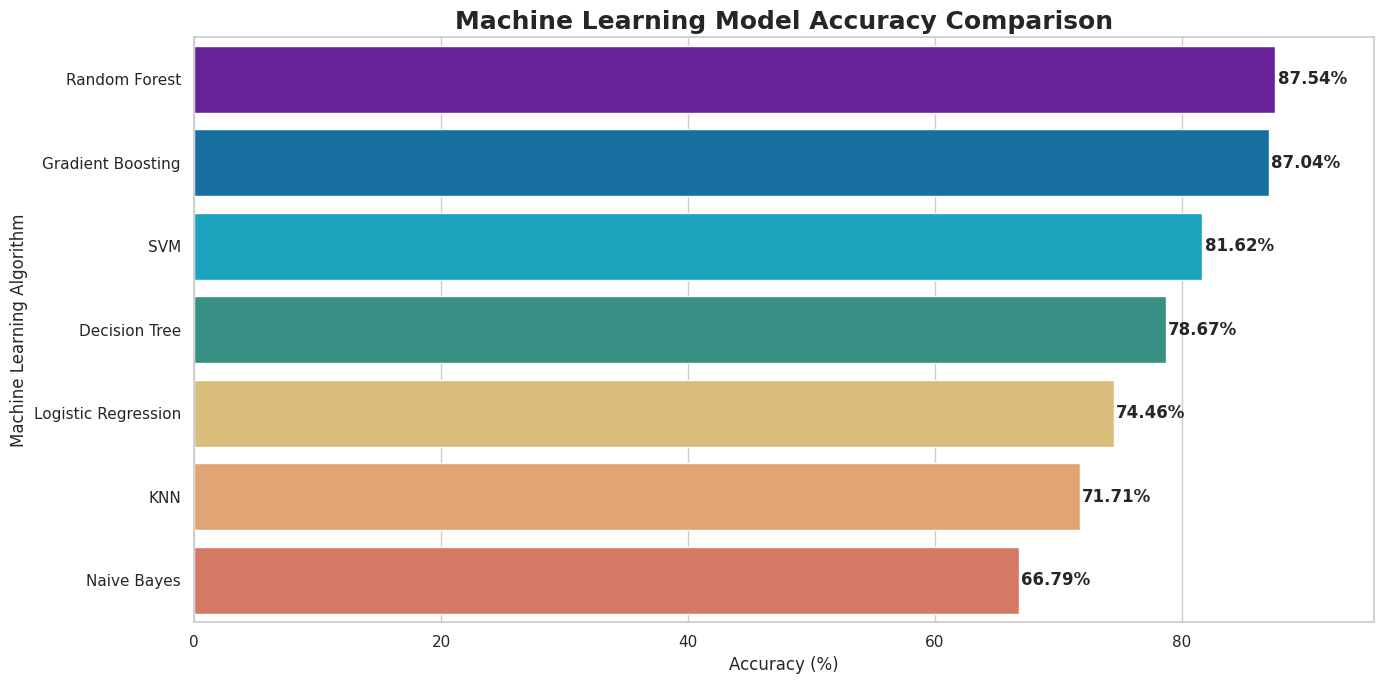

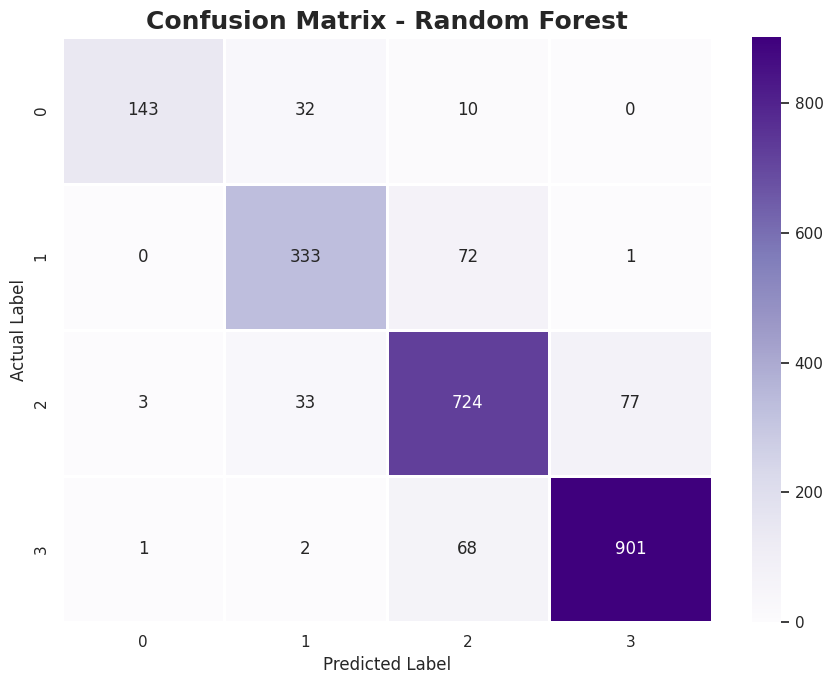


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      0.77      0.86       185
           1       0.83      0.82      0.83       406
           2       0.83      0.86      0.85       837
           3       0.92      0.93      0.92       972

    accuracy                           0.88      2400
   macro avg       0.89      0.85      0.86      2400
weighted avg       0.88      0.88      0.88      2400


ACTUAL VS PREDICTED
   Actual Predicted
0       3         3
1       3         3
2       2         2
3       3         3
4       3         3
5       2         1
6       2         2
7       2         2
8       3         3
9       1         2
10      3         3
11      3         3
12      2         2
13      0         0
14      1         1
15      3         3
16      2         2
17      1         1
18      1         1
19      2         2

FINAL PREDICTION ACCURACY
Correct Predictions : 2101
Total Predictions   : 2400
Accuracy            

In [14]:
# ============================================================
# CANDIDATE RELEVANCE PREDICTION - COMPLETE ML PIPELINE
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

target = "relevance_label"

print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

print(df[target].value_counts())

drop_columns = [
    "candidate_id",
    "job_role_display",
    "edu_level_name"
]

df_ml = df.drop(
    columns=drop_columns,
    errors="ignore"
)

print("\nColumns after removing unnecessary columns:")
print(df_ml.columns.tolist())


# ============================================================
# 6. HANDLE MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES BEFORE PROCESSING")
print("=" * 70)

print(df_ml.isnull().sum())


# Fill categorical columns with mode
categorical_columns = df_ml.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:

    df_ml[column] = df_ml[column].fillna(
        df_ml[column].mode()[0]
    )


# Fill numerical columns with median
numerical_columns = df_ml.select_dtypes(
    include=np.number
).columns

for column in numerical_columns:

    df_ml[column] = df_ml[column].fillna(
        df_ml[column].median()
    )


print("\nMissing values after processing:")
print(df_ml.isnull().sum().sum())


# ============================================================
# 7. SEPARATE FEATURES AND TARGET
# ============================================================

X = df_ml.drop(
    columns=[target]
)

y = df_ml[target]

print("\n" + "=" * 70)
print("FEATURES AND TARGET")
print("=" * 70)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())


# ============================================================
# 8. LABEL ENCODING FOR CATEGORICAL FEATURES
# ============================================================

print("\n" + "=" * 70)
print("LABEL ENCODING")
print("=" * 70)

label_encoders = {}

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical columns:")

for column in categorical_features:

    print(column)

    le = LabelEncoder()

    X[column] = le.fit_transform(
        X[column].astype(str)
    )

    label_encoders[column] = le


# ============================================================
# 9. LABEL ENCODE TARGET VARIABLE
# ============================================================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    y.astype(str)
)

print("\nTarget classes:")

for number, class_name in enumerate(
    target_encoder.classes_
):

    print(
        number,
        "->",
        class_name
    )


# ============================================================
# 10. CHECK ENCODED DATA
# ============================================================

print("\n" + "=" * 70)
print("ENCODED FEATURES")
print("=" * 70)

print(X.head())

print("\nEncoded Target:")
print(y[:10])


# ============================================================
# 11. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ============================================================
# 12. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ============================================================
# 13. DEFINE ML MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf",
            random_state=42
        ),

    "Naive Bayes":
        GaussianNB()
}


# ============================================================
# 14. TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}

print("\n" + "=" * 70)
print("MODEL TRAINING")
print("=" * 70)

for model_name, model in models.items():

    print("\nTraining:", model_name)

    # Models that benefit from scaling
    if model_name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

        predictions = model.predict(
            X_test_scaled
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    accuracy_percentage = accuracy * 100

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_percentage
    })

    trained_models[model_name] = model

    print(
        f"{model_name} Accuracy: "
        f"{accuracy_percentage:.2f}%"
    )


# ============================================================
# 15. CREATE ACCURACY COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODEL ACCURACY COMPARISON")
print("=" * 70)

print(results_df)


# ============================================================
# 16. BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy"]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print("Best Model :", best_model_name)
print(
    "Accuracy   :",
    f"{best_accuracy:.2f}%"
)


# ============================================================
# 17. ACCURACY BAR CHART
# ============================================================

plt.figure(
    figsize=(14, 7)
)

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette=[
        "#6A0DAD",
        "#0077B6",
        "#00B4D8",
        "#2A9D8F",
        "#E9C46A",
        "#F4A261",
        "#E76F51"
    ]
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Accuracy (%)"
)

plt.ylabel(
    "Machine Learning Algorithm"
)

# Display percentage on bars
for index, value in enumerate(
    results_df["Accuracy"]
):

    plt.text(
        value + 0.2,
        index,
        f"{value:.2f}%",
        va="center",
        fontweight="bold"
    )

plt.xlim(
    0,
    min(105, results_df["Accuracy"].max() + 8)
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. BEST MODEL PREDICTION
# ============================================================

best_model = trained_models[
    best_model_name
]

if best_model_name in [
    "Logistic Regression",
    "KNN",
    "SVM"
]:

    best_predictions = best_model.predict(
        X_test_scaled
    )

else:

    best_predictions = best_model.predict(
        X_test
    )


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    linewidths=1
)

plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)


# ============================================================
# 21. ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({

    "Actual": target_encoder.inverse_transform(
        y_test
    ),

    "Predicted": target_encoder.inverse_transform(
        best_predictions
    )
})

print("\n" + "=" * 70)
print("ACTUAL VS PREDICTED")
print("=" * 70)

print(comparison.head(20))


# ============================================================
# 22. PREDICTION ACCURACY
# ============================================================

correct_predictions = (
    comparison["Actual"]
    ==
    comparison["Predicted"]
).sum()

total_predictions = len(
    comparison
)

prediction_accuracy = (
    correct_predictions /
    total_predictions
) * 100

print("\n" + "=" * 70)
print("FINAL PREDICTION ACCURACY")
print("=" * 70)

print(
    f"Correct Predictions : "
    f"{correct_predictions}"
)

print(
    f"Total Predictions   : "
    f"{total_predictions}"
)

print(
    f"Accuracy            : "
    f"{prediction_accuracy:.2f}%"
)

## Thank you..pls upvote!!!!!!!!